# ■ 딥러닝 컴페티션

컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.


## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

## 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

# 시작

In [3]:
!pip install gdown

# 코랩 작업 디렉토리에 train2.csv 다운
!gdown https://drive.google.com/uc?id=1pAcddVInRCXpFVaax5rnu2bFah788JAU

Downloading...
From: https://drive.google.com/uc?id=1pAcddVInRCXpFVaax5rnu2bFah788JAU
To: /content/train2.csv
100% 25.3M/25.3M [00:00<00:00, 174MB/s]


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report

In [5]:
# 파일 열기
file_path = '/content/train2.csv'
data = pd.read_csv(file_path)

data.head(2)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.82262,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.94496,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good


## EDA  


### 데이터 타입과 결측치 확인  

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

In [5]:
# # 숫자형만
# numeric_cols = data.select_dtypes(include='number').columns.tolist()

# # 숫자형 컬럼과 각각의 값 보기
# for col in numeric_cols:
#   print(col, ":")
#   print(data[col].unique())
#   print()

In [6]:
# 범주형만
object_cols = data.select_dtypes(include='object').columns.tolist()

# 범주형 컬럼과 각각의 값 보기
for col in object_cols:
  print(col, ":")
  print(data[col].unique())
  print()

display(data['Type_of_Loan'].value_counts())
display(data['Payment_of_Min_Amount'].value_counts())

Name :
['Aaron Maashoh' 'Rick Rothackerj' 'Langep' ... 'Chris Wickhamm'
 'Sarah McBridec' 'Nicks']

Occupation :
['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect']

Type_of_Loan :
['auto loan,credit-builder loan,personal loan,home equity loan'
 'credit-builder loan' 'auto loan,auto loan,not specified' ...
 'home equity loan,auto loan,auto loan,auto loan'
 'payday loan,student loan,mortgage loan,not specified'
 'personal loan,auto loan,mortgage loan,student loan,student loan']

Credit_Mix :
['Good' 'Standard' 'Bad']

Payment_of_Min_Amount :
['No' 'NM' 'Yes']

Payment_Behaviour :
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' 'High_spent_Large_value_payments']

Credit_Score :
['Good' 'Standard' 'Poor']



,count
Type_of_Loan,
No Data,11408
not specified,1408
credit-builder loan,1280
personal loan,1272
debt consolidation loan,1264
...,...
"debt consolidation loan,auto loan,personal loan,debt consolidation loan,student loan,credit-builder loan",8
"student loan,auto loan,student loan,credit-builder loan,home equity loan,debt consolidation loan,debt consolidation loan",8
"debt consolidation loan,personal loan,mortgage loan,personal loan,not specified,mortgage loan,home equity loan",8


,count
Payment_of_Min_Amount,
Yes,52326
No,35667
NM,12007


**의사 결측치 존재 확인**  

**Type_of_Loan**  
No Data	11408  
not specified 1408  
> 컬럼 특성상 유니크 값이 많으므로 결측치를 대체값으로 채우지 않는다.  
대체값 넣어버리면 데이터 왜곡 생길 가능성 있음.  

**Payment_of_Min_Amount**  
NM	12007  
> 값들이 바이너리 값이므로 이것도 결측치를 그대로 둔다.  

결측 자체가 하나의 정보가 될 수도 있음 (신용 위험성과 관련 있다거나)  
-> "unknown"으로 별도의 카테고리화  


In [7]:
# 결측치 처리 - "unknown"으로 대체 (인코딩하기 위해 문자열로)
data['Type_of_Loan'] = data['Type_of_Loan'].replace(['No Data', 'not specified'], "unknown")
data['Payment_of_Min_Amount'] = data['Payment_of_Min_Amount'].replace(['NM'], "unknown")

### 타겟 분포 확인

In [8]:
# 신용등급(타겟) 분포 확인

credit_score_order = ['Good', 'Standard', 'Poor']

display(data['Credit_Score'].value_counts().reindex(credit_score_order))
display(data['Credit_Score'].value_counts(normalize=True))

,count
Credit_Score,
Good,17828
Standard,53174
Poor,28998


,proportion
Credit_Score,
Standard,0.53174
Poor,0.28998
Good,0.17828


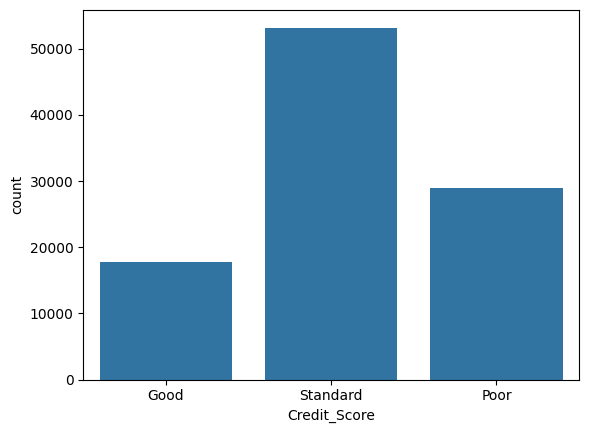

In [9]:
sns.countplot(data=data, x='Credit_Score', order=credit_score_order)
plt.show()

Standard에 고객이 몰려있고, Good 비율이 가장 낮음  
-> 클래스 불균형 문제  
-> 이후 모델 학습 시 다음을 고려한다.  
- stratify split 적용
- class weight 실험


### 상관관계 분석 & 시각화  

- 신용등급과 주요 변수 간 관계를 시각화해보고 신용등급에 영향을 줄 가능성 높은 피처를 확인한다.  
- 이를 근거로 피처 셀렉션 진행한다. (하지만 셀렉한 몇몇 피처만 넣었을 때 성능이 더 안 좋아서 폐기)  
- 금융 데이터 패턴 해석

<Axes: xlabel='Credit_Score', ylabel='Annual_Income'>

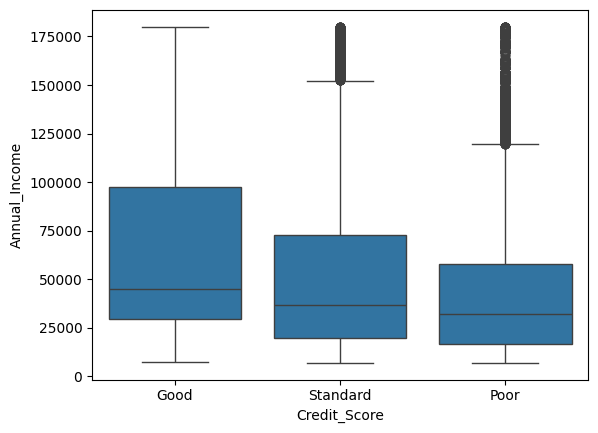

In [10]:
# 신용점수와 연간소득
sns.boxplot(x='Credit_Score', y='Annual_Income', data=data)

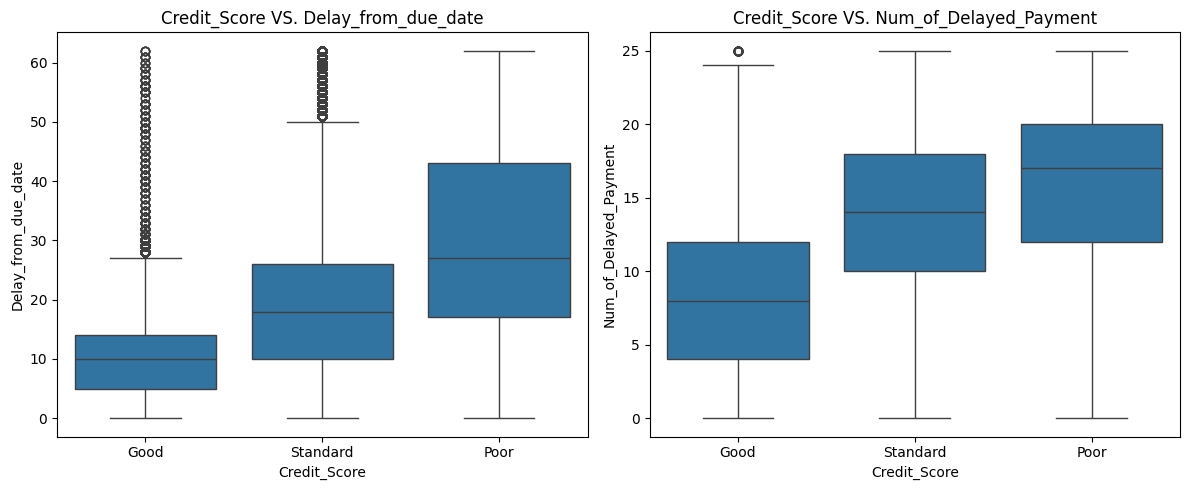

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 신용점수와 연체 일수
sns.boxplot(
  x='Credit_Score',
  y='Delay_from_due_date',
  data=data,
  ax=axes[0]
)
axes[0].set_title('Credit_Score VS. Delay_from_due_date')

# 신용점수와 연체 횟수
sns.boxplot(
  x='Credit_Score',
  y='Num_of_Delayed_Payment',
  data=data,
  ax=axes[1]
)
axes[1].set_title('Credit_Score VS. Num_of_Delayed_Payment')

plt.tight_layout()
plt.show()

<Axes: xlabel='Credit_Score', ylabel='Outstanding_Debt'>

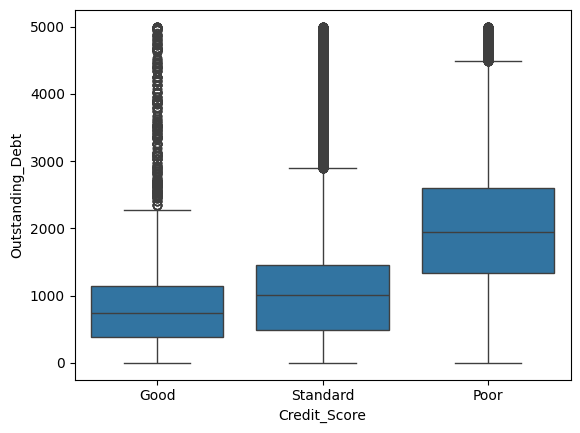

In [13]:
# 신용등급과 미지급 잔액 - 부채
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=data)

,Credit_Utilization_Ratio
Credit_Score,
Good,32.686107
Poor,31.986146
Standard,32.313820


<Axes: xlabel='Credit_Utilization_Ratio', ylabel='Count'>

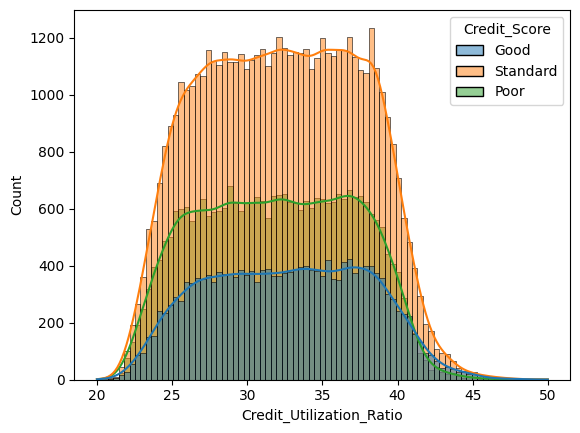

In [12]:
# 신용등급별 신용카드 이용률
display(data.groupby('Credit_Score')['Credit_Utilization_Ratio'].mean())
sns.histplot(data=data, x='Credit_Utilization_Ratio', hue='Credit_Score', kde=True)

<Axes: xlabel='Credit_Score', ylabel='Credit_History_Age'>

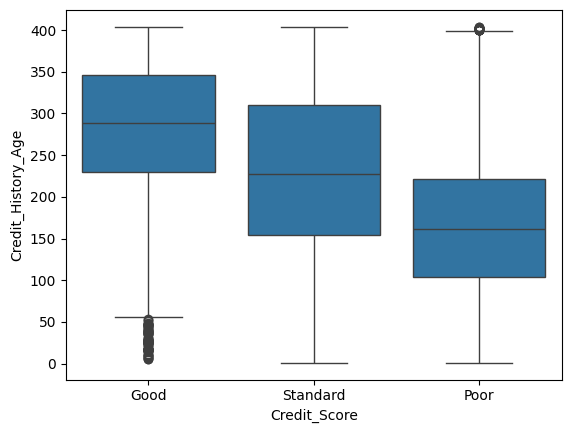

In [14]:
# 신용등급과 신용 이력 기간
sns.boxplot(x='Credit_Score', y='Credit_History_Age', data=data)

Credit_Score,Good,Poor,Standard
Occupation,,,
Accountant,1205,2037,3502
Architect,1233,1855,3736
Developer,1210,1924,3586
Doctor,1164,1804,3600
Engineer,1264,2094,3506
Entrepreneur,1185,2033,3430
Journalist,1254,1840,3442
Lawyer,1259,1965,3872
Manager,1190,1856,3386


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Scientist'),
  Text(1, 0, 'Teacher'),
  Text(2, 0, 'Engineer'),
  Text(3, 0, 'Entrepreneur'),
  Text(4, 0, 'Developer'),
  Text(5, 0, 'Lawyer'),
  Text(6, 0, 'Media_Manager'),
  Text(7, 0, 'Doctor'),
  Text(8, 0, 'Journalist'),
  Text(9, 0, 'Manager'),
  Text(10, 0, 'Accountant'),
  Text(11, 0, 'Musician'),
  Text(12, 0, 'Mechanic'),
  Text(13, 0, 'Writer'),
  Text(14, 0, 'Architect')])

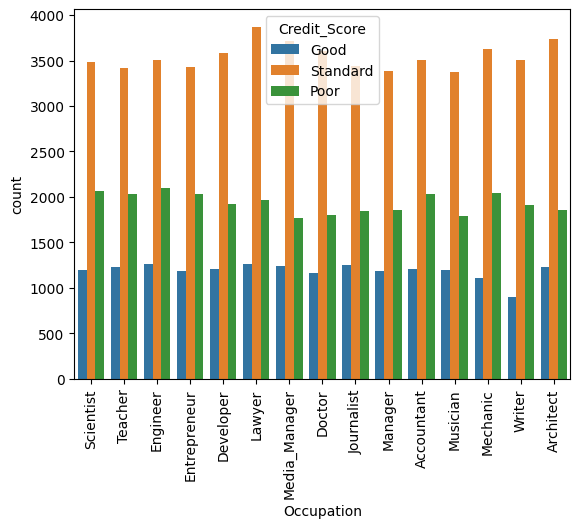

In [15]:
# 직업별 신용등급 분포
display(pd.crosstab(data['Occupation'], data['Credit_Score']))

sns.countplot(data=data, x='Occupation', hue='Credit_Score')
plt.xticks(rotation=90)

모든 직군에서 Standard > Poor > Good 순  

<Axes: xlabel='Payment_of_Min_Amount', ylabel='count'>

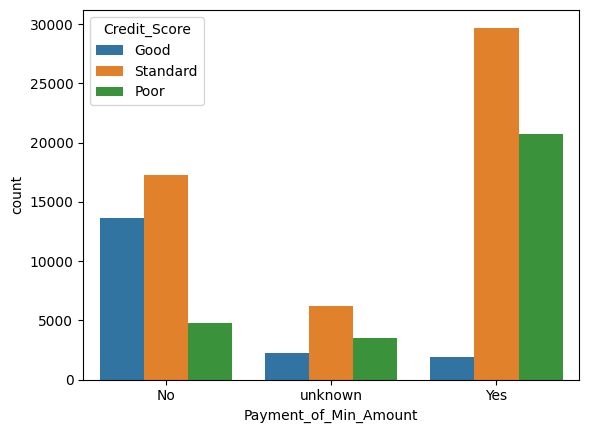

In [16]:
# 최소 금액만 납부하는지 여부
sns.countplot(data=data, x='Payment_of_Min_Amount', hue='Credit_Score')

<Axes: xlabel='Month', ylabel='count'>

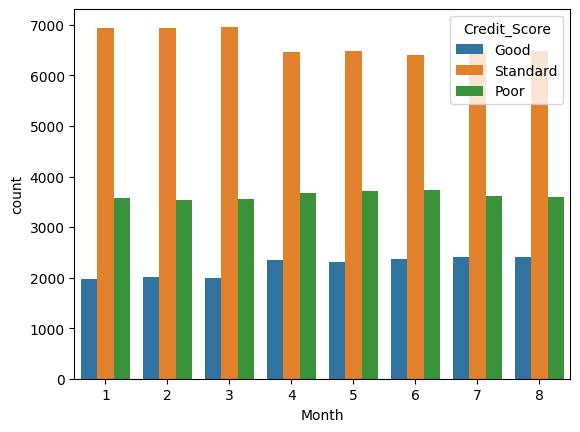

In [18]:
# 월별 신용점수 패턴
sns.countplot(data=data, x='Month', hue='Credit_Score')

# 월별로 별로 변화 없음
# 특정 월의 눈에 띄는 특징 없음

<Axes: xlabel='Credit_Score', ylabel='Num_of_Loan'>

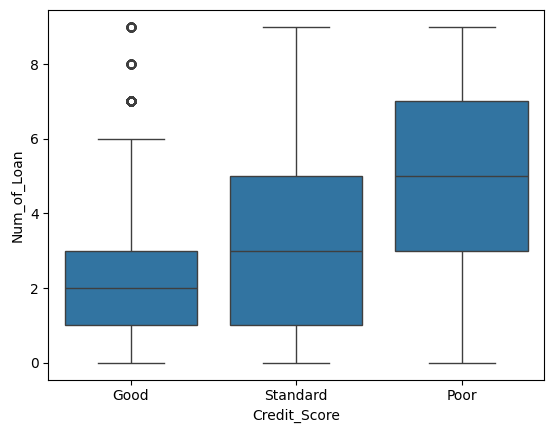

In [19]:
# 신용등급과 대출 개수
sns.boxplot(x='Credit_Score', y='Num_of_Loan', data=data)

# 대출 개수가 많으면 신용등급이 낮다. 대출 개수가 많으면 대출 잔액도 높을 가능성이 있음

<Axes: xlabel='Credit_Score', ylabel='Amount_invested_monthly'>

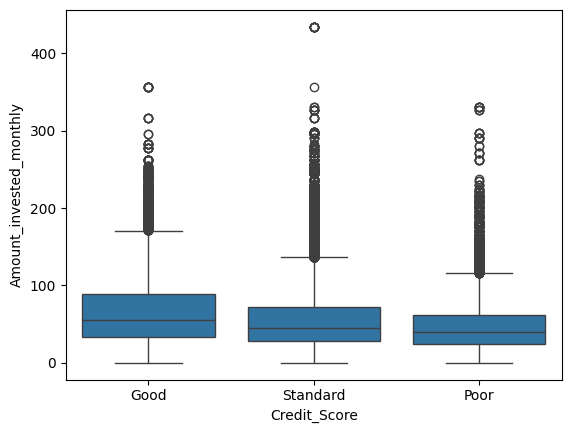

In [20]:
# 신용등급과 투자 금액
sns.boxplot(x='Credit_Score', y='Amount_invested_monthly', data=data)

각 등급마다 이상치가 많음  

#### 주요 관찰 결과  

- 연체 일수와 연체 횟수가 증가할수록 신용등급이 낮아지는 경향
- Outstanding_Debt(부채)가 높을수록 Poor 비율 증가 (이상치 많음)  
- Credit_History_Age(신용 이력)이 길수록 신용등급 높음
- Num_of_Loan(대출 개수)이 많을수록 신용등급이 낮아지는 경향
- 모든 직군에서 Standard 비율이 가장 높음
- 월별 패턴은 큰 차이가 없음  

## 전처리  

In [8]:
# 학습에 불필요한 컬럼 제거
data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

In [9]:
# 범주형 피처(X) 인코딩

categorical_cols = [
  col for col in data.select_dtypes(include='object').columns
  if col != 'Credit_Score'
]

encoders = {}

for col in categorical_cols:
  # LabelEncoder는 순서가 있다고 착각할 수 있으므로 OrdinalEncoder 사용
  encoder = OrdinalEncoder(
      handle_unknown='use_encoded_value',
      unknown_value=-1
  )
  data[[col]] = encoder.fit_transform(data[[col]])
  data[col] = data[col].astype(int)   # float 타입으로 변환되었으므로 int로 변환해줌

  encoders[col] = encoder

# 타겟(y) 인코딩 - 타겟용 인코더는 따로 보관
target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])


In [17]:
# 디코딩
# encoders['Occupation'].inverse_transform([[0]])

- unknown category 처리 가능  
- 추후 inverse transform 가능  
하도록 encoder를 저장하였다.

<Axes: >

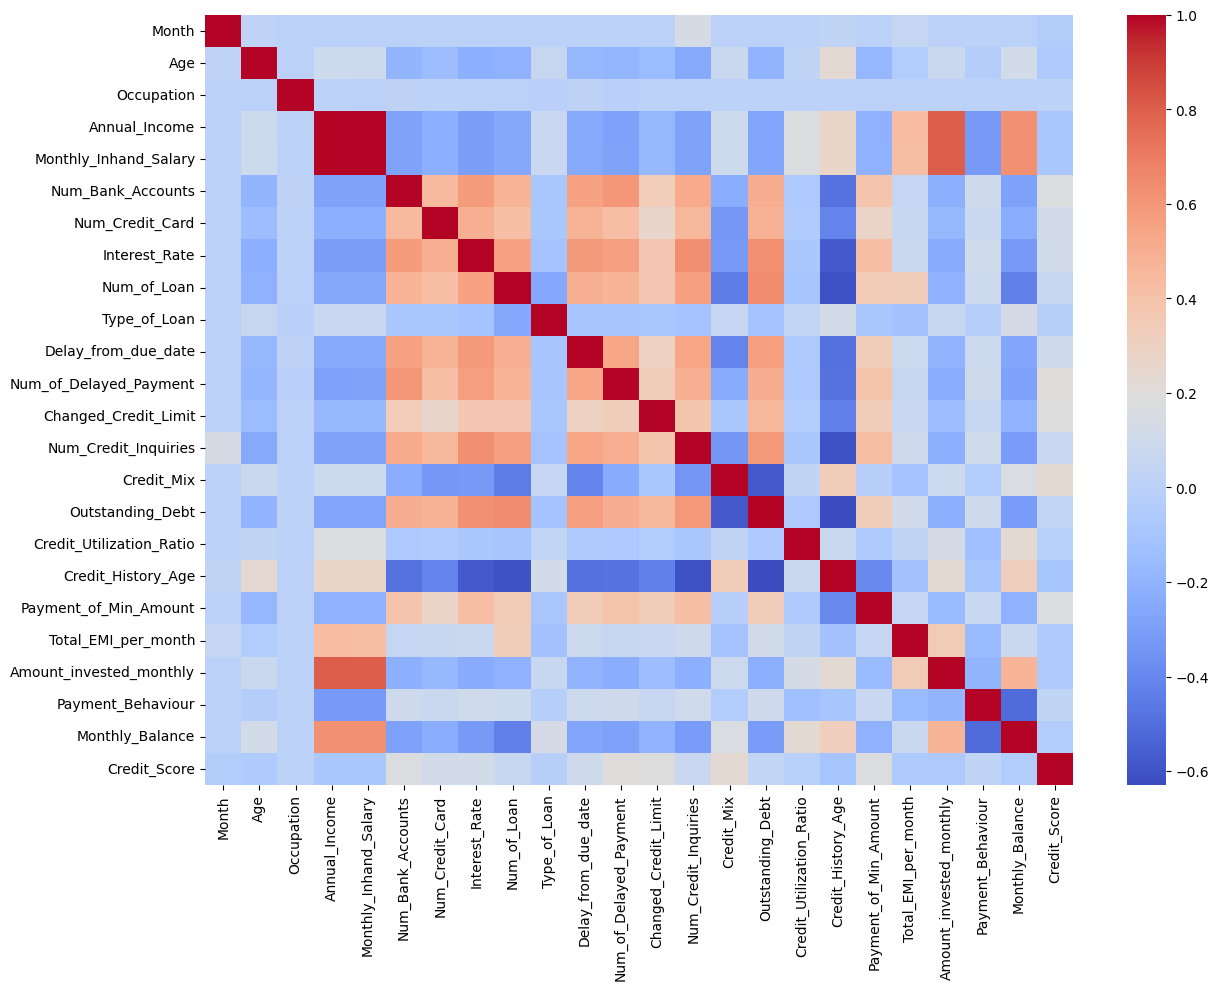

In [19]:
# 상관관계 히트맵
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')

Credit_Score과 상관도 높은 피처:  
Credit_Mix, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Bank_Accounts, Payment_of_Min_Amount (순서 상관 없이)  

피처 셀렉션에 참고 예정  

## 학습 및 분류

In [24]:
# 입력(X), 정답(y) 분리
X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

# 피처 스케일링 - 이상치가 많으므로 중앙값과 IQR로 스케일링하는 RobustScaler 사용
scaler = RobustScaler()
X = scaler.fit_transform(X)

# train, test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# # 클래스 불균형 보정용 가중치 계산
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# # tensor 변환
# class_weights = torch.tensor(
#     class_weights,
#     dtype=torch.float32
# )

### MLP  

Multi Layer Perceptron은 딥러닝 분류의 기본 모델이다.

- tabular 데이터의 기본 baseline 모델
- 구현이 단순하고 해석이 쉬움
- 다양한 하이퍼파라미터 실험 가능


또한 성능 개선을 위해 다음 튜닝을 수행하였다.

- Batch Normalization 추가
- Dropout 추가
- hidden layer 크기 증가
- learning rate 감소

In [ ]:
# PyTorch Dataset 클래스 정의
class CreditScoreDataset(Dataset):
  # 데이터 저장
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.long)

  # 데이터 개수 반환
  def __len__(self):
    return len(self.y)

  # 인덱스에 해당하는 데이터 반환
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

# 데이터셋 생성
train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

# 데이터셋 생성, 배치 쪼개어서 전달 (미니배치)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [43]:
# Multi Layer Perceptron 모델 클래스 정의
class MLP(nn.Module):
  def __init__(self, input_size):
    super(MLP, self).__init__()

    # 성능 향상을 위한 BatchNorm, Dropout 추가
    self.model = nn.Sequential(
      nn.Linear(input_size, 256),
      nn.BatchNorm1d(256),
      nn.ReLU(),
      nn.Dropout(0.2),

      nn.Linear(256, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Dropout(0.2),

      nn.Linear(128, 64),
      nn.ReLU(),

      nn.Linear(64, 3)
    )

  # 순전파
  def forward(self, x):
    return self.model(x)

# GPU 모드 켜기
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 입력 피처 개수
input_size = X_train.shape[1]
# 모델 생성 및 GPU로 이동
mlp_model = MLP(input_size).to(device)
# 손실 함수 - 다중 분류라서 CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss(
#     weight=class_weights.to(device)     # class weight 적용
# )
# 최적화 함수
optimizer = optim.Adam(mlp_model.parameters(), lr=0.0003)


In [44]:
# 모델 학습
epochs = 20

for epoch in range(epochs):
  # 학습 모드 ----------
  mlp_model.train()
  running_loss = 0.0  # epoch 손실값

  # 학습 정확도
  correct_train = 0
  total_train = 0

  # 배치 단위로 학습
  for inputs, targets in train_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    outputs = mlp_model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)                  # 예측 클래스 선택
    total_train += targets.size(0)                        # 전체 데이터 수 누적
    correct_train += (predicted == targets).sum().item()  # 맞힌 개수 누적

  # 평가 모드 ----------
  mlp_model.eval()

  # 평가 정확도
  correct_val = 0
  total_val = 0

  with torch.no_grad():
    # 평가도 똑같이 배치 단위로
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = mlp_model(inputs)
      _, predicted = torch.max(outputs, 1)
      total_val += targets.size(0)
      correct_val += (predicted == targets).sum().item()

  # epoch마다 학습/평가 정확도 출력
  train_accuracy = 100 * correct_train / total_train
  val_accuracy = 100 * correct_val / total_val
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
        f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.7090, 학습 정확도: 67.31%, 평가 정확도: 69.98%
Epoch [2/20], Loss: 0.6741, 학습 정확도: 69.22%, 평가 정확도: 70.40%
Epoch [3/20], Loss: 0.6635, 학습 정확도: 69.79%, 평가 정확도: 70.74%
Epoch [4/20], Loss: 0.6568, 학습 정확도: 69.98%, 평가 정확도: 70.86%
Epoch [5/20], Loss: 0.6517, 학습 정확도: 70.28%, 평가 정확도: 70.81%
Epoch [6/20], Loss: 0.6485, 학습 정확도: 70.32%, 평가 정확도: 70.93%
Epoch [7/20], Loss: 0.6435, 학습 정확도: 70.46%, 평가 정확도: 71.06%
Epoch [8/20], Loss: 0.6434, 학습 정확도: 70.56%, 평가 정확도: 71.25%
Epoch [9/20], Loss: 0.6401, 학습 정확도: 70.80%, 평가 정확도: 71.42%
Epoch [10/20], Loss: 0.6379, 학습 정확도: 70.78%, 평가 정확도: 71.25%
Epoch [11/20], Loss: 0.6363, 학습 정확도: 70.91%, 평가 정확도: 71.27%
Epoch [12/20], Loss: 0.6329, 학습 정확도: 71.06%, 평가 정확도: 71.47%
Epoch [13/20], Loss: 0.6316, 학습 정확도: 71.06%, 평가 정확도: 71.48%
Epoch [14/20], Loss: 0.6306, 학습 정확도: 71.15%, 평가 정확도: 71.39%
Epoch [15/20], Loss: 0.6288, 학습 정확도: 71.17%, 평가 정확도: 71.06%
Epoch [16/20], Loss: 0.6261, 학습 정확도: 71.34%, 평가 정확도: 71.58%
Epoch [17/20], Loss: 0.6272, 학습 정확도: 71.25%, 평가 정

#### 모델 성능 개선 시도  

기본 MLP 구조 대비 다음과 같은 개선을 적용하였다.

1. Batch Normalization
- 학습 안정화
- gradient 흐름 개선
- 학습 속도 향상

2. Dropout
- 과적합 방지

3. hidden layer 확장
- 128 → 64 → 32에서
- 256 → 128 → 64 구조로 변경

4. learning rate 감소
- 더 안정적인 수렴 유도

5. class imbalance 보정 실험
- CrossEntropyLoss에 class weight 적용 실험 수행

다만 class weight 적용 시 accuracy는 감소하였다.  
소수 클래스를 더 잘 맞추도록 학습되면서 다수 클래스 정확도가 일부 감소했기 때문으로 해석된다.

### TabNet으로 다시 학습 및 분류  

- tabular 데이터 특화 딥러닝 모델
- feature selection을 attention 기반으로 자동 수행
- 범주형 변수 처리에 강점
- 금융 데이터와 같은 structured data에 적합

In [1]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00


In [25]:
from pytorch_tabnet.tab_model import TabNetClassifier

# GPU 모드
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# TabNetClassifier 초기화 및 학습
# tabnet_model = TabNetClassifier(device_name=device.type)
tabnet_model = TabNetClassifier(
  optimizer_fn=torch.optim.Adam,
  optimizer_params=dict(lr=2e-2),

  scheduler_params={
    "step_size":20,
    "gamma":0.9
  },

  scheduler_fn=torch.optim.lr_scheduler.StepLR,

  mask_type='entmax'
)

tabnet_model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],  # 조기종료용 평가데이터
  eval_metric=['accuracy'],     # 평가 metric
  max_epochs=100,               # 최대 100번 학습
  patience=10,                  # 조기종료 기회는 10번
  batch_size=1024,               # 미니배치 사이즈
  drop_last=False               # 마지막 배치 학습함
)

# 예측
preds = tabnet_model.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, preds)
print(f'Accuracy: {accuracy:.4f}')

# 분류 리포트
print(classification_report(y_test, preds))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.78265 | val_0_accuracy: 0.6792  |  0:00:03s
epoch 1  | loss: 0.68223 | val_0_accuracy: 0.69805 |  0:00:06s
epoch 2  | loss: 0.65945 | val_0_accuracy: 0.708   |  0:00:11s
epoch 3  | loss: 0.64945 | val_0_accuracy: 0.70935 |  0:00:14s
epoch 4  | loss: 0.64363 | val_0_accuracy: 0.71265 |  0:00:17s
epoch 5  | loss: 0.63835 | val_0_accuracy: 0.7119  |  0:00:22s
epoch 6  | loss: 0.63742 | val_0_accuracy: 0.7136  |  0:00:25s
epoch 7  | loss: 0.63551 | val_0_accuracy: 0.71365 |  0:00:29s
epoch 8  | loss: 0.63454 | val_0_accuracy: 0.7127  |  0:00:32s
epoch 9  | loss: 0.63425 | val_0_accuracy: 0.71115 |  0:00:36s
epoch 10 | loss: 0.63208 | val_0_accuracy: 0.7145  |  0:00:40s
epoch 11 | loss: 0.63009 | val_0_accuracy: 0.71475 |  0:00:43s
epoch 12 | loss: 0.62956 | val_0_accuracy: 0.71415 |  0:00:47s
epoch 13 | loss: 0.62766 | val_0_accuracy: 0.71125 |  0:00:51s
epoch 14 | loss: 0.62846 | val_0_accuracy: 0.7159  |  0:00:54s
epoch 15 | loss: 0.62907 | val_0_accuracy: 0.7158  |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Accuracy: 0.7272
              precision    recall  f1-score   support

           0       0.63      0.68      0.66      3566
           1       0.74      0.69      0.71      5799
           2       0.76      0.76      0.76     10635

    accuracy                           0.73     20000
   macro avg       0.71      0.71      0.71     20000
weighted avg       0.73      0.73      0.73     20000



#### 모델 성능 개선 시도  

다음 하이퍼파라미터를 조정하였다.

- learning rate: 2e-2
- batch_size: 1024
- max_epochs: 100
- patience: 10
- mask_type: entmax

또한 early stopping(patience)을 사용하여 과적합을 방지하였다.

In [14]:
# 피처 중요도

feature_importances = pd.Series(
    tabnet_model.feature_importances_,
    index=data.drop('Credit_Score', axis=1).columns
)

print(
    feature_importances.sort_values(ascending=False)
)

Credit_Mix                  4.222125e-01
Interest_Rate               1.201937e-01
Outstanding_Debt            7.356681e-02
Num_Credit_Inquiries        7.340280e-02
Month                       6.557969e-02
Payment_of_Min_Amount       5.576792e-02
Credit_History_Age          4.178262e-02
Changed_Credit_Limit        4.016467e-02
Num_Credit_Card             2.626449e-02
Payment_Behaviour           2.553543e-02
Total_EMI_per_month         2.132547e-02
Num_Bank_Accounts           1.868625e-02
Monthly_Inhand_Salary       1.551749e-02
Num_of_Loan                 1.637610e-07
Age                         0.000000e+00
Annual_Income               0.000000e+00
Occupation                  0.000000e+00
Type_of_Loan                0.000000e+00
Delay_from_due_date         0.000000e+00
Num_of_Delayed_Payment      0.000000e+00
Credit_Utilization_Ratio    0.000000e+00
Amount_invested_monthly     0.000000e+00
Monthly_Balance             0.000000e+00
dtype: float64


#### 피처 중요도 분석  

TabNet의 feature importance를 사용하여 중요 변수들을 분석하였다.

이를 통해:
- 실제 모델이 어떤 feature를 중요하게 사용하는지 확인
- EDA 결과와 비교
- 신용등급에 영향을 주는 핵심 변수 해석

EDA 결과와 비교했을 때, Credit_Mix가 동일하게 중요도가 높게 측정되었다.  

#### 추가 개선 방안  

1. transformer 기반 모델로 바꾸어보기
- TabTransformer/FT-Transformer
2. 피처 파생변수 생성
3. 데이터 불균형 보정
- SMOTE (그러나 범주형 데이터가 많아서 적절하지 않을 수 있음)
- weight 조정
4. 모델 앙상블
- 트리 기반 ML 모델(e.g. XGBoost)과 DL 모델 합쳐보기


### TabTransformer  

MLP와 TabNet 이후 Transformer 기반 tabular 모델인 TabTransformer를 추가 학습하였다.

- 범주형 데이터를 embedding 기반으로 학습 가능
- self-attention을 통해 feature 간 관계 학습 가능
- tabular 데이터에서 높은 성능 보임
- 범주형 변수가 많은 금융 데이터에 적합
- 범주형/숫자형 컬럼 분리 필요

In [26]:
!pip install tab-transformer-pytorch

In [29]:
from tab_transformer_pytorch import TabTransformer

# 범주형 / 연속형 컬럼 인덱스 분리
feature_columns = data.drop('Credit_Score', axis=1).columns.tolist()
# 범주형 컬럼들
categorical_cols = [col for col in object_cols if col in feature_columns]
# 연속형 컬럼들
continuous_cols = [col for col in feature_columns if col not in categorical_cols]

# 컬럼 인덱스 추출
categorical_idx = [feature_columns.index(col) for col in categorical_cols]
continuous_idx = [feature_columns.index(col) for col in continuous_cols]

# 범주형 / 연속형 데이터 분리
X_train_categ = torch.tensor(X_train[:, categorical_idx], dtype=torch.int64)
X_train_cont = torch.tensor(X_train[:, continuous_idx], dtype=torch.float32)
X_test_categ = torch.tensor(X_test[:, categorical_idx], dtype=torch.int64)
X_test_cont = torch.tensor(X_test[:, continuous_idx], dtype=torch.float32)

# 정답 텐서 변환
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Dataset 클래스 정의
class CreditDataset(Dataset):
  def __init__(self, x_categ, x_cont, y):
    self.x_categ = x_categ
    self.x_cont = x_cont
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return (
      self.x_categ[idx],
      self.x_cont[idx],
      self.y[idx]
    )


# Dataset / DataLoader 생성
train_dataset = CreditDataset(X_train_categ, X_train_cont, y_train_tensor)
test_dataset = CreditDataset(X_test_categ, X_test_cont, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# 각 범주형 컬럼의 unique 개수
categories = []

for col in categorical_cols:
  n_unique = data[col].nunique()
  categories.append(n_unique)

categories = tuple(categories)

# print(categories)

# GPU 모드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TabTransformer 모델 정의
tt_model = TabTransformer(
  categories=categories,                # 범주형 변수별 unique 개수
  num_continuous=len(continuous_cols),  # 연속형 변수 개수
  dim=32,                               # 모델 차원
  dim_out=3,                            # 다중분류 클래스 개수
  depth=6,                              # 모델 깊이
  heads=8,                              # multi-head attention
  attn_dropout=0.1,                     # dropout
  ff_dropout=0.1,
  mlp_hidden_mults=(4, 2),              # 마지막 MLP hidden 크기 비율
  mlp_act=nn.ReLU()                     # 활성화 함수
).to(device)


# 손실 함수 / 최적화 함수
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tt_model.parameters(), lr=0.001)

# 모델 학습
epochs = 50

for epoch in range(epochs):
  # 학습 모드 ---------
  tt_model.train()

  running_loss = 0.0
  correct_train = 0
  total_train = 0

  for x_categ, x_cont, targets in train_loader:
    x_categ = x_categ.to(device)
    x_cont = x_cont.to(device)
    targets = targets.to(device)

    optimizer.zero_grad()

    # 예측
    outputs = tt_model(x_categ, x_cont)

    # 손실 계산
    loss = criterion(outputs, targets)

    loss.backward()
    optimizer.step()
    running_loss += loss.item()

    # 정확도 계산
    _, predicted = torch.max(outputs, 1)
    total_train += targets.size(0)
    correct_train += (
        predicted == targets
    ).sum().item()

  # 평가 모드 ---------

  tt_model.eval()

  correct_test = 0
  total_test = 0

  all_preds = []
  all_targets = []

  with torch.no_grad():
    for x_categ, x_cont, targets in test_loader:

      x_categ = x_categ.to(device)
      x_cont = x_cont.to(device)
      targets = targets.to(device)

      outputs = tt_model(x_categ, x_cont)

      _, predicted = torch.max(outputs, 1)
      total_test += targets.size(0)

      correct_test += (predicted == targets).sum().item()

      all_preds.extend(predicted.cpu().numpy())
      all_targets.extend(targets.cpu().numpy())

  # epoch 결과 출력
  train_acc = (100 * correct_train / total_train)
  test_acc = (100 * correct_test / total_test)
  print(
    f'Epoch [{epoch+1}/{epochs}] '
    f'Loss: {running_loss/len(train_loader):.4f} '
    f'학습 정확도: {train_acc:.2f}% '
    f'평가 정확도: {test_acc:.2f}%'
  )

# 최종 평가
print("\nClassification Report\n")
print(
  classification_report(
    all_targets,
    all_preds
  )
)

Epoch [1/50] Loss: 0.7491 Train Acc: 65.05% Test Acc: 67.80%
Epoch [2/50] Loss: 0.6919 Train Acc: 68.14% Test Acc: 68.31%
Epoch [3/50] Loss: 0.6758 Train Acc: 68.87% Test Acc: 68.60%
Epoch [4/50] Loss: 0.6662 Train Acc: 69.30% Test Acc: 69.41%
Epoch [5/50] Loss: 0.6593 Train Acc: 69.71% Test Acc: 69.82%
Epoch [6/50] Loss: 0.6535 Train Acc: 69.89% Test Acc: 69.98%
Epoch [7/50] Loss: 0.6487 Train Acc: 70.26% Test Acc: 69.65%
Epoch [8/50] Loss: 0.6444 Train Acc: 70.44% Test Acc: 70.33%
Epoch [9/50] Loss: 0.6386 Train Acc: 70.73% Test Acc: 70.27%
Epoch [10/50] Loss: 0.6334 Train Acc: 70.97% Test Acc: 70.34%
Epoch [11/50] Loss: 0.6274 Train Acc: 71.24% Test Acc: 70.38%
Epoch [12/50] Loss: 0.6216 Train Acc: 71.54% Test Acc: 71.22%
Epoch [13/50] Loss: 0.6134 Train Acc: 71.76% Test Acc: 70.95%
Epoch [14/50] Loss: 0.6049 Train Acc: 72.28% Test Acc: 71.37%
Epoch [15/50] Loss: 0.5946 Train Acc: 72.84% Test Acc: 71.47%
Epoch [16/50] Loss: 0.5827 Train Acc: 73.31% Test Acc: 71.91%
Epoch [17/50] Los

세 가지 모델 중 가장 높은 test 성능(accuracy 76%)을 보였으며,  
주요 하이퍼파라미터는 다음과 같이 사용하였다.  
- dim=32
- depth=6
- heads=8
- dropout=0.1  